# Exploratory Data Analysis.

This notebook contains **exploratory data analysis** of Student Performance Dataset.

The goal is to understand the structure of the data and identify factors that influence students' final grade (**G3**), which is later transformed into a multiclass classification problem.

## Covered in this notebook:

* Data loading and initial inspection
* Feature Overview and data types
* Target variable (**G3**) distribution analysis
* Transformation of G3 into categorical classes (A/B/C)
* Analysis of numerical features and their relationship with the target.
* Analysis of categorical features and their impact on student performance
* Key insights and observations

----
## Importing Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
import sys
import scipy

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

# Step 1. Data Loading and Initial Inspection

In [2]:
sys.path.append(str(Path("..").resolve()))

DATA_DIR = Path("../dataset/student")

csv_files = list(DATA_DIR.glob("*.csv"))

csv_files

[PosixPath('../dataset/student/student-mat.csv'),
 PosixPath('../dataset/student/student-por.csv')]

The original [Dataset](https://archive.ics.uci.edu/dataset/320/student+performance) consists of two separate CSV files representing student performance in different subjects:

* Mathematics
* Portuguese language

For this project, only portuguese language dataset is used to ensure a focused analysis and modeling pipeline.

----

In [3]:
df = pd.read_csv(csv_files[1], sep=';')

df.head(7)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13
5,GP,M,16,U,LE3,T,4,3,services,other,reputation,mother,1,2,0,no,yes,no,yes,yes,yes,yes,no,5,4,2,1,2,5,6,12,12,13
6,GP,M,16,U,LE3,T,2,2,other,other,home,mother,1,2,0,no,no,no,no,yes,yes,yes,no,4,4,4,1,1,3,0,13,12,13


In [4]:
df.shape

(649, 33)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


The dataset contains 649 rows and 33 features, including target variable (G3). An initial inspection suggests that the dataset is well-structured and does not contain any explicit missing values or duplicates enties.

Most of the numeric features are binary or categorical in nature, leaving only a small number of continuous variables suitable for outlier detection. A quick review using `df.describe()` does not reveal any obvious *outliers*.

----

# Step 2. Target Distribution Analysis.

Before performing the distribution analysis, the target variable **G3** is transformed into a categorical feature (A, B, C) to convert the problem into a multiclass classification task. The resulting labels are stored in a new column (**G3_class**) in the original DataFrame.

In [8]:
import src.preprocessing as preprocessing

df = preprocessing.create_class_target_variable(df)

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,G3_class
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11,B
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11,B
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12,B
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14,A
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13,A


In [9]:
df.groupby('G3_class')['G3'].describe()

,count,mean,std,min,25%,50%,75%,max
G3_class,,,,,,,,
C,20.0,1.200000,2.353050,0.0,0.0,0.0,0.25,6.0
B,353.0,10.320113,1.328049,7.0,10.0,10.0,11.00,12.0
A,276.0,14.710145,1.580347,13.0,13.0,14.0,16.00,19.0


In [10]:
round(df['G3_class'].value_counts(normalize=True) * 100, 2)

G3_class
B    54.39
A    42.53
C     3.08
Name: proportion, dtype: float64

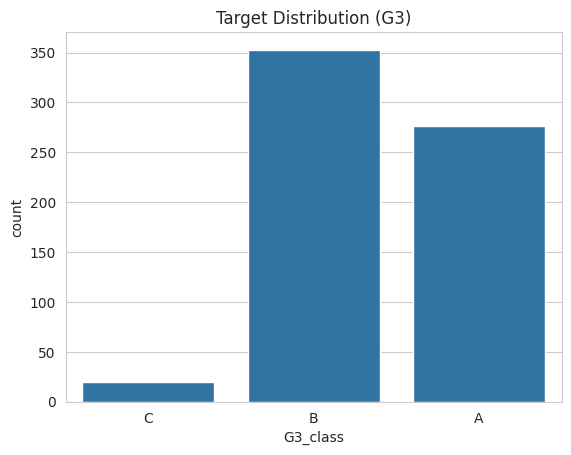

In [11]:
sns.countplot(data=df, x='G3_class')
plt.title("Target Distribution (G3)")
plt.show()

After creating `G3_class` variable as the main target, the analysis shows a strong class imbalance across the three garde categories (A, B and C). Only a small proportion of students (~ 3%) belong to class C, while the majority are distributed between classes A and B, with higher grades being more common.

----

## Target Distribution Along Numerical Features

This section focuses on the analysis of numerical features in the dataset.

Although these variables are technically numerical, many of them represent ordinal or categorical-like features (e.g. `Medu`, `Fedu`, `studytime`).

Therefore, traditional outlier detection methods such as IQR-based filtering are not particulary informative for this dataset.

In [12]:
# Select numerical features
num_features = df.select_dtypes(['int']).columns.tolist()

# Remove target variables
num_features = [el for el in num_features if el not in ('G1', 'G2', 'G3')]

df[num_features].skew().sort_values(ascending=False)

failures      3.092699
Dalc          2.141913
absences      2.020694
traveltime    1.247648
studytime     0.699619
Walc          0.635904
age           0.416795
Fedu          0.215343
goout        -0.008580
Medu         -0.029950
freetime     -0.181277
health       -0.500656
famrel       -1.105934
dtype: float64

Several numerical features demonstrate noticeable skewness patterns.

Features such as `failure`, `Dalc`, `absences` and `traveltime` exhibit strong positive skewness, indicating that most observations are concentrated in lower-value categories while only a small subset of students reaches higher values. This behavior is expected for ordinal educational behavioral variables with limited cardinality.

In contrast, `famrel` shows strong negative skewness, suggesting that the majority of students report relatively high family relationship quality. Similarly, `health` demonstrates moderate left skew, indicating a tendency toward higher self-reported health scores.

Most remaining features appear approximately symmetric or only moderately skewed, suggesting relatively balanced distributions across their ordinal categories.

----

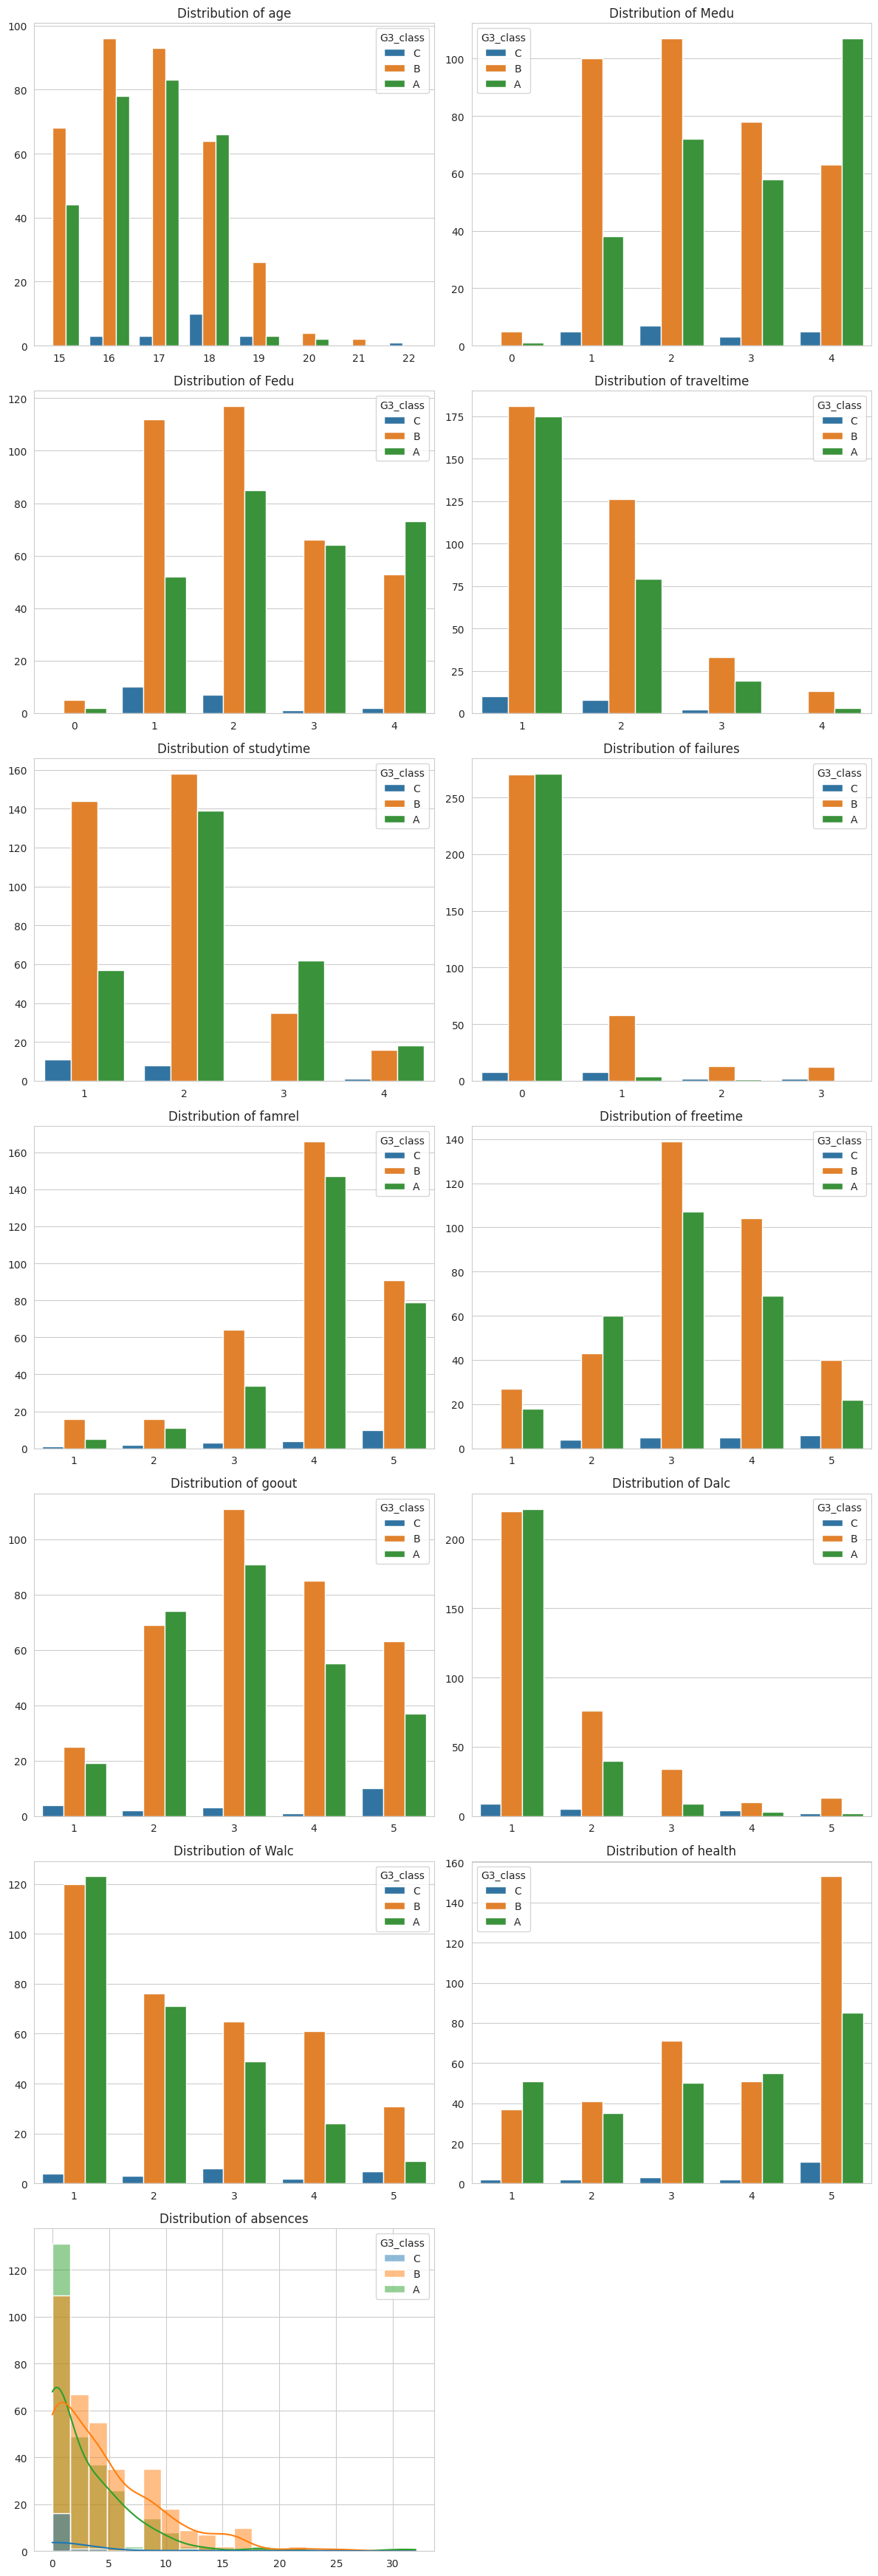

In [13]:
n_cols = 2
n_rows = (len(num_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows*5))

axes = axes.flatten()

for i, col in enumerate(num_features):
    if col == 'absences':
        sns.histplot(
            data=df,
            x=col,
            hue="G3_class",
            bins=20,
            kde=True,
            ax=axes[i]
        )
    else:
        sns.countplot(
            data=df,
            x=col,
            hue="G3_class",
            ax=axes[i]
        )
    
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(len(num_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Visual inspection of the distributions further supports these findings and highlights noticeable differences between grade classes across several behavioral and academic variables. These observations suggests that certain numerical features may contain meaningful predictive information for the downstream multiclass classification task.

----

## ANOVA Analysis

A one-way ANOVA test was conducted to assess whether the mean values of numerical features differ significantly across the grade categories (`G3_class`).

The **F-statistic** measures the ratio of between-class variance to within-class variance, while the **p-value** indicates whether these differences are statistically significant.

In [14]:
from scipy.stats import f_oneway

anova_results = []

for col in num_features:

    group_A = df[df['G3_class'] == 'A'][col]
    group_B = df[df['G3_class'] == 'B'][col]
    group_C = df[df['G3_class'] == 'C'][col]

    stat, p = f_oneway(group_A, group_B, group_C)

    anova_results.append({
        "feature": col,
        "F_statistic": stat,
        "p_value": p
    })

anova_df = pd.DataFrame(anova_results)

anova_df = anova_df.sort_values(by="p_value")

anova_df

,feature,F_statistic,p_value
5,failures,40.077909,3.912651e-17
1,Medu,21.192064,1.218259e-09
9,Dalc,20.164770,3.199218e-09
4,studytime,18.226425,1.993595e-08
2,Fedu,14.301759,8.363822e-07
10,Walc,13.713571,1.469718e-06
12,absences,10.357422,3.736312e-05
0,age,9.654512,7.388236e-05
11,health,5.713993,3.468475e-03
3,traveltime,5.503550,4.265531e-03


### Key Observations

The most statistically significatn features are:

* `failures`
* `Medu`
* `Dalc`
* `studytime`

These variables show the highest **F-statistic** and extremely low **p-value**, indicating strong differences in their distributions across grade cateegories.

------

Features such as:

* `Fedu`
* `Walc`
* `absences`
* `age`

show meaningful but less pronounced separation between classes.

----

Variables like:

* `health`
* `traveltime`
* `freetime`
* `goout`
* `famrel`

exhibit relatively low **F-statistics**, suggesting weaker relationships with academic performance. In particular, `famrel` is not statistically significant at the *0.05 level*.

### Overall Conclusion

The ANOVA results indicate that only a subset of numerical features provides strong discriminatory power across grade categories. In particular, academic histoty (`failures`), parental education (`Medu`, `Fedu`), and behavioral factors (`Dalc`, `studytime`) emerge as the most influantial variables.

These features will be prioritized in the subsequent deep-dive analysis to better understand their relationship with student performance and their potential predictive value for modeling.

----

## Prioritized Numerical Features Analysis

In [15]:
top_num_features = [
    "failures", 
    "Medu",
    "Fedu",
    "Dalc",
    "studytime",
    "Walc"
]

groupped_means = round(df.groupby('G3_class')[top_num_features].agg(['mean', 'median']), 2)
groupped_means

failures         Medu         Fedu         Dalc        studytime  \
             mean median  mean median  mean median  mean median      mean   
G3_class                                                                    
C            0.90    1.0  2.40    2.0  1.75    1.5  2.25    2.0      1.55   
B            0.34    0.0  2.27    2.0  2.14    2.0  1.64    1.0      1.78   
A            0.02    0.0  2.84    3.0  2.56    2.0  1.27    1.0      2.15   

                 Walc         
         median  mean median  
G3_class                      
C           1.0  3.05    3.0  
B           2.0  2.45    2.0  
A           2.0  2.00    2.0

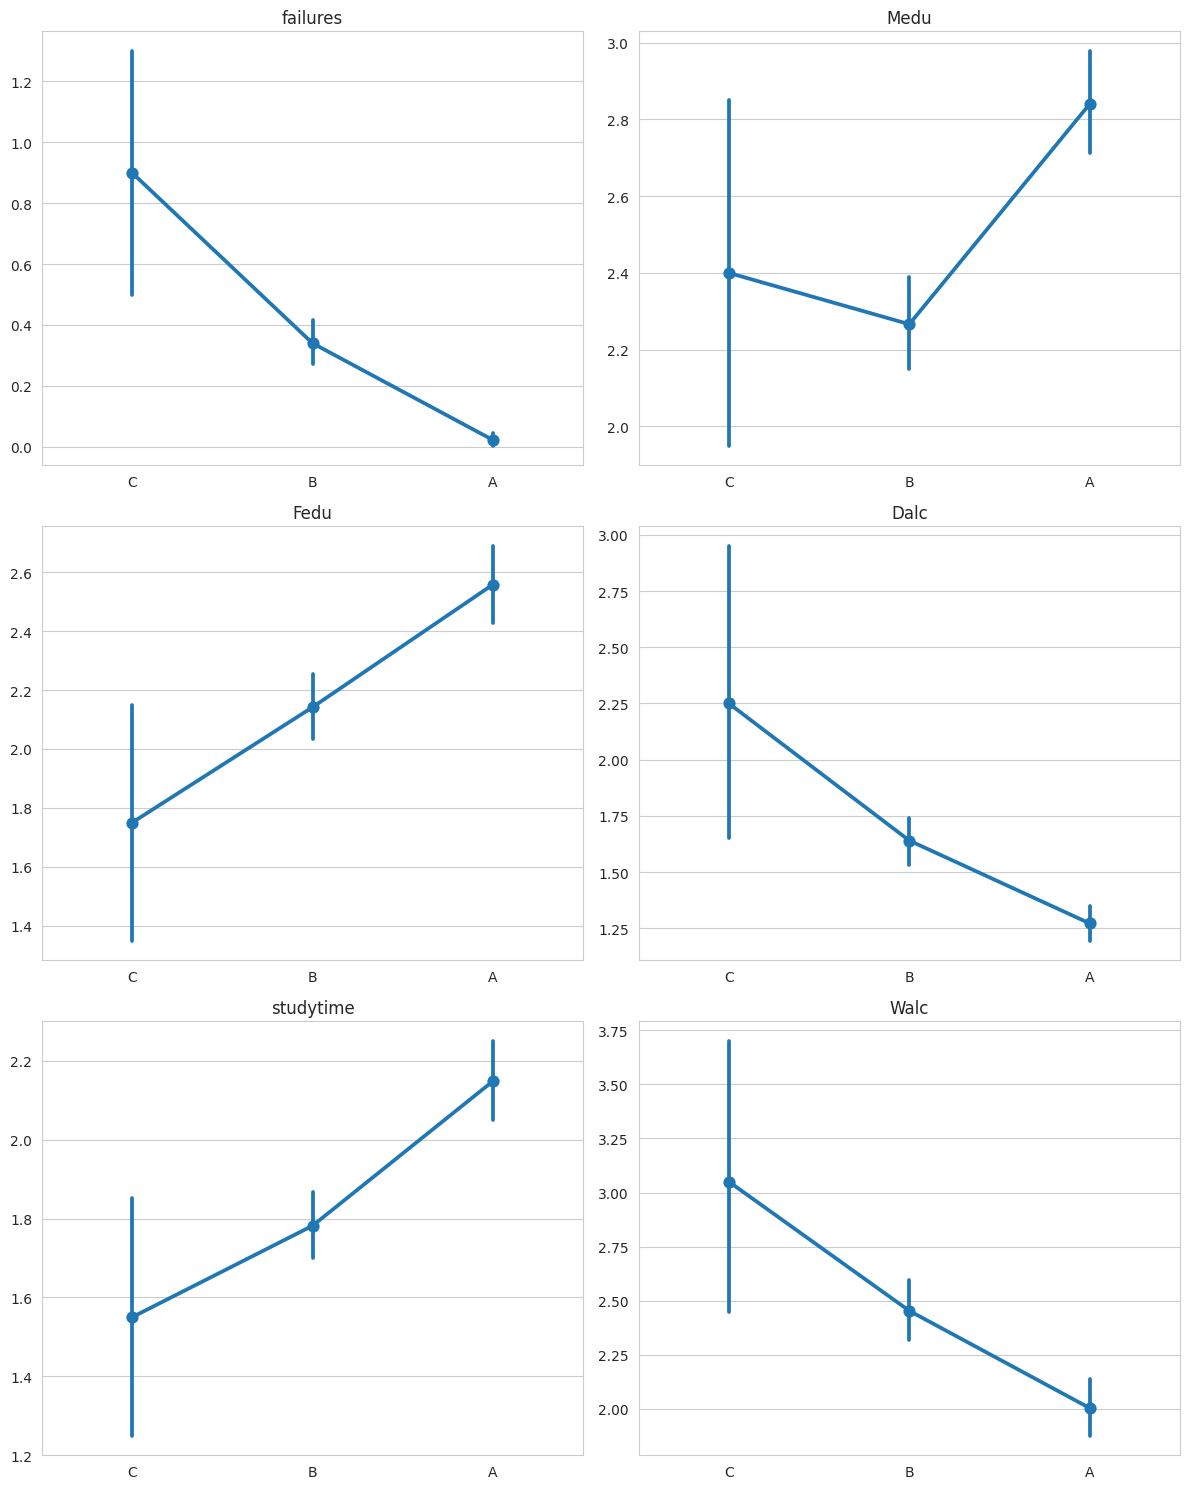

In [16]:
n_cols = 2
n_rows = (len(top_num_features) + n_cols - 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows*5))

axes = axes.flatten()

for i, col in enumerate(top_num_features):
    sns.pointplot(
        data=df,
        x="G3_class",
        y=col,
        ax=axes[i]
    )
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].set_title(f"{col}")

plt.tight_layout()
plt.show()

----

### Prioritized Feature Analysis Conclusion

The group-wise analysis and pointplot visualizations reveal several clear and interpretable trends across grade categories.

The `failures` features demonstrates the strongest separation betweeen classes. Students in the lowest performing category (C) exhibit substantially higher average failure counts compared to higher-performing students, while class `A` studednts almost entirely lack previous failures. This suggests that past academic difficulties are strongly associated with lower future performance.

Study-related variables also display meaningful patterns. Studednts in higher-performing categories tend to report greater `studytime`, indicating a positive relationship between study habits and accademic success.

Parental education variables (`Medu` and `Fedu`) show consistent upward trends across grade classes. Students with stronger accademic outcomes generally come from families with higher parental education levels, suggesting that family education background may contribute positively to student achievement.

Behavioral variables such as `Dalc` and `Walc` exhibit inverse relationships with academic performance. Lower-performing students demonstrate noticeably higher alcohol consumption levels, particularly for weekend alcohol use (`Walc`), which may indicate negative behavioral asssociated with lower accademic outcomes.

Overall, the pointplots confirm the ANOVA findings by showing clear monotonic trends and meaningful class separaation for several key numerical features. These variables are likely to provide strong predictive value for the downstream multiclass classification task.

----

## Target Distribution Along Categorical Features.

This section is focused on the analysis of categorical features in the dataset.

These variables describe demographic, social and behavioral aspects of students and are expected to influence adacademic performance.

The target value `G3_class` represents student performance grouped in three categories (A, B, C), which allows us to study how categorical attributes differ across achievements levels.

In [17]:
cat_features = df.select_dtypes(['object', 'string']).columns.tolist()

cat_features

['school',
 'sex',
 'address',
 'famsize',
 'Pstatus',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic']

In [18]:
df[cat_features].nunique()

school        2
sex           2
address       2
famsize       2
Pstatus       2
Mjob          5
Fjob          5
reason        4
guardian      3
schoolsup     2
famsup        2
paid          2
activities    2
nursery       2
higher        2
internet      2
romantic      2
dtype: int64

Most categorical variables in the dataset are binary features with only two unique values, while several variables such as `Mjob`, `Fjob`, `reason` and `guardian` contain a small number of additional categories.

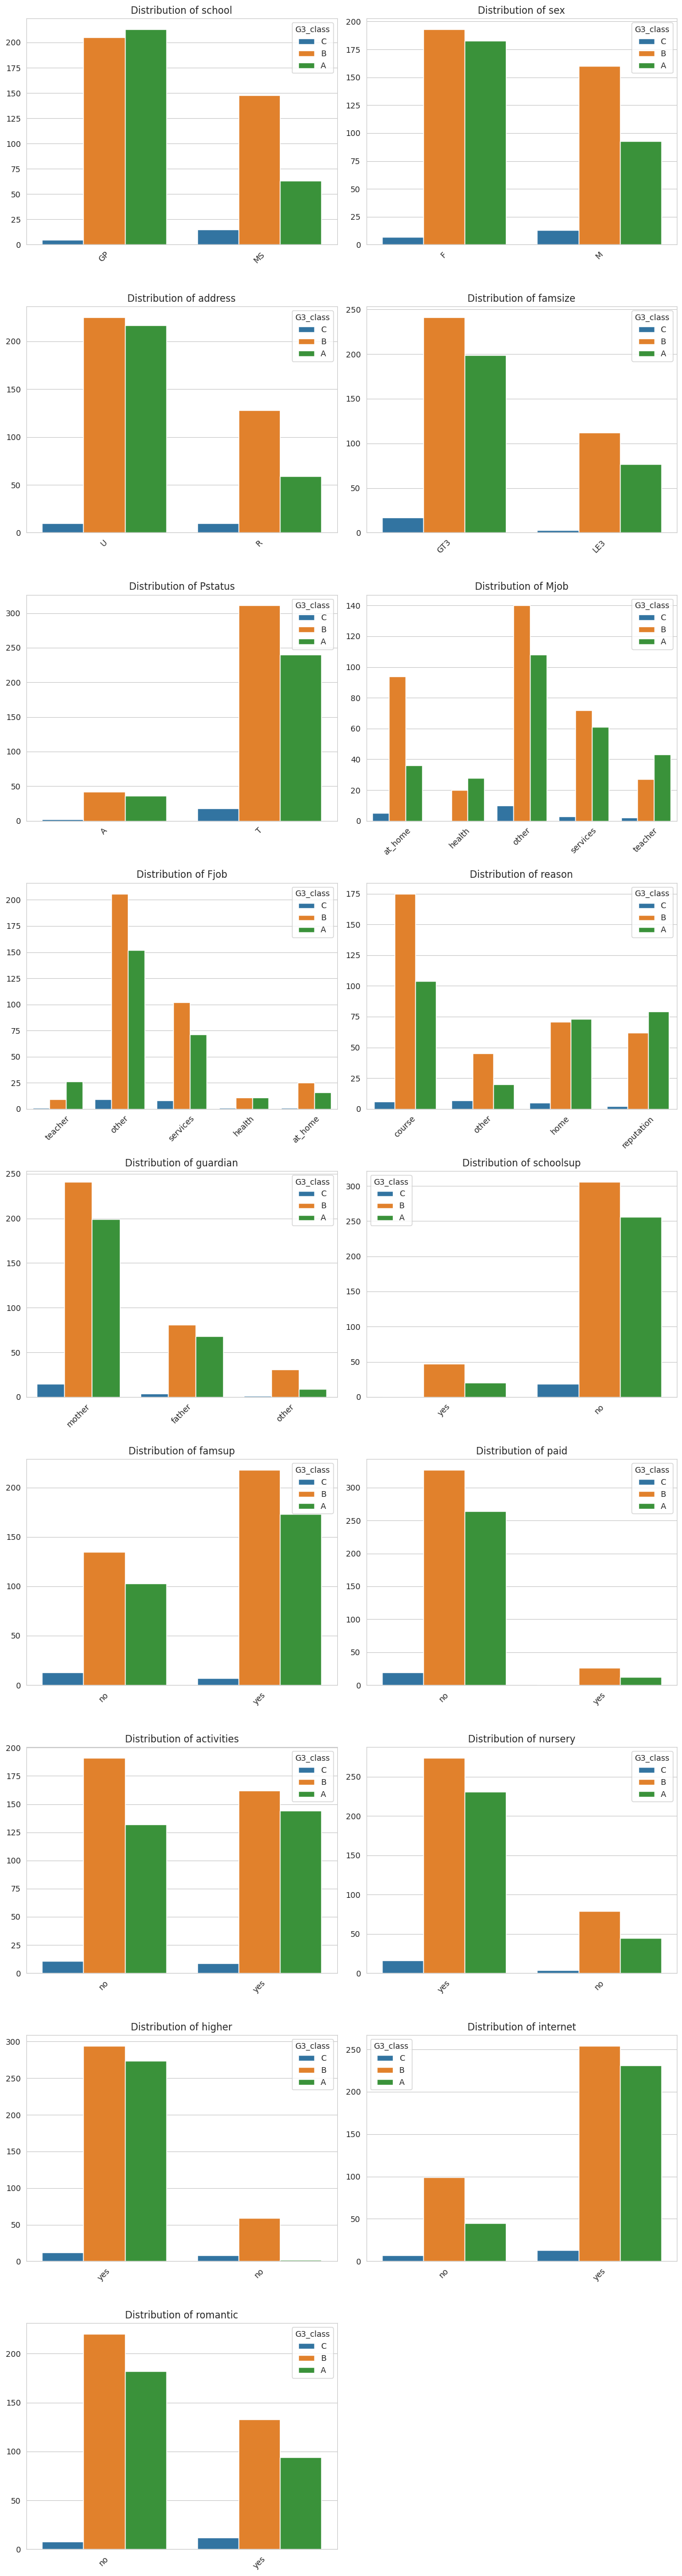

In [19]:
n_cols = 2
n_rows = (len(cat_features) + n_cols - 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows*5))

axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.countplot(
        data=df,
        x=col,
        hue='G3_class',
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].tick_params(rotation=45, axis='x')

for j in range(len(cat_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [20]:
from scipy.stats import chi2_contingency

chi_resutls = []

for col in cat_features:

    count_table = pd.crosstab(df[col], df['G3_class'])

    chi2, p, dof, expected = chi2_contingency(count_table)

    chi_resutls.append({
        "features": col,
        "chi2_statistic": chi2,
        "p_value": p
    })

chi_df = pd.DataFrame(chi_resutls)

chi_df = chi_df.sort_values(by="chi2_statistic", ascending=False)
chi_df

,features,chi2_statistic,p_value
14,higher,60.409834,7.623794e-14
0,school,39.573845,2.550638e-09
7,reason,33.456101,8.565874e-06
5,Mjob,29.570640,2.516760e-04
2,address,19.998417,4.543587e-05
6,Fjob,16.536923,3.530898e-02
1,sex,13.581768,1.123975e-03
15,internet,13.551144,1.141317e-03
8,guardian,8.224582,8.368936e-02
9,schoolsup,6.740606,3.437923e-02


### Key Observations

The most strongly associated categorical features with academic performance are:

* `higher`
* `school`
* `reason`
* `Mjob`

These variables exhibit high *Chi-Square* statistic and extremely low *p-value*, indicating strong dependence between these features and grade categories.

----

Features such as:

* `address`
* `Fjob`
* `sex`
* `internet`

show statistically significant but weaker associations, suggesting a moderate relationship with academic performance.

----

The following features show limited or no statistically significant association with `G3_class`:

* `guardian`
* `schoolsup`
* `famsup`
* `romantic`
* `nursery`
* `famsize`
* `activities`
* `paid`
* `Pstatus`

These variables likely have minimal direct influence on grade outcomes on this dataset.

----

### Overall Conclusion

The Chi-Square analysis reveals that only a subset of categorical features in meaningfully asssociated with student performance categories. In particular, academic aspirations (`higher`), school-related factors (`school`, `reason`), and parental occupation (`Mjob`) demonstrate the strongest relationships with `G3_class`.

## Prioritized categorical feature analysis

To better understand the relationship between categorical features and student performance, normalized contingency tables were computed for the most significant variables indentified through the Chi-Square test.

In [21]:
top_cat_features = ["higher", "school", "reason", "Mjob", "address"]

for col in top_cat_features:
    display(pd.crosstab(df[col], df['G3_class'], normalize='index').round(2))

G3_class,C,B,A
higher,,,
no,0.12,0.86,0.03
yes,0.02,0.51,0.47


G3_class,C,B,A
school,,,
GP,0.01,0.48,0.50
MS,0.07,0.65,0.28


G3_class,C,B,A
reason,,,
course,0.02,0.61,0.36
home,0.03,0.48,0.49
other,0.10,0.62,0.28
reputation,0.01,0.43,0.55


G3_class,C,B,A
Mjob,,,
at_home,0.04,0.70,0.27
health,0.00,0.42,0.58
other,0.04,0.54,0.42
services,0.02,0.53,0.45
teacher,0.03,0.38,0.60


G3_class,C,B,A
address,,,
R,0.05,0.65,0.30
U,0.02,0.50,0.48


The normalized distribbution clearly highlight strong class separation for features such as `higher`, `school` and `Mjob`, while other variables show more uniform distributions across grade categories. 

# EDA Conclusion

The exploratory data analysis identified a set of numerical and categorical features that are most strongly associated with student performance (`G3_class`). The results from statistical tests (ANOVA and Chi-Square) and visual analysis consistently highlight a subset of variables with strong predictive signal.

## Key Findings Summary

Across both numerical and categorical analyses, the following patterns were observed:

* Academic history and study behavior are the most informative signal sources.
* Parental education and school-related context also contribute meaningfully to performance differences.
* Social and extracurricular variables are generally show weaker associations with the target.

## Most Strong Numerical Features (Top based on ANOVA results & trends)

* `failures`
* `studytime`
* `Medu`
* `Fedu`
* `Dalc`
* `Walc`
* `absences`
* `age`

## Most Strong Categorical Features (Top based on Chi-Square results)

* `higher`
* `school`
* `reason`
* `Mjob`
* `address`
* `sex`
* `internet`
* `schoolsup`

## Final Insight

The dataset exhibits a clear separation between academic, behavioral and social factors in terms of predictive strength. Academic and behavioral dominate the signal, while social features play a secondary role. This suggests that student performance is primarily driven by study-related and family-education-related factors rather than extracurricular or social variables.

----

## Implications for Modeling 

These features provide a solid foundation for predictive modeling. Proper encoding of categorical variables and careful handling of ordinal numerical features will be important, Given the nature of the relationships observed, tree-based or ensemble models are likely to perform well due to their ability to capture non-linear interactions.